<a href="https://colab.research.google.com/github/Reshmatr2407/Python/blob/python/DeepLearning_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve,
                             roc_auc_score, classification_report)


# read the file

In [10]:
titanic_df=pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


DATA PREPROCESSING

1.Handling Missing Values

In [11]:
# Identify missing values
print(titanic_df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


 Dropping Irrelevant Columns

In [12]:
# Drop the original Name column
titanic_df.drop('Name', axis=1, inplace=True)
# Drop the original Cabin column
titanic_df.drop('Cabin', axis=1, inplace=True)
# Drop the original Ticket column
titanic_df.drop('Ticket', axis=1, inplace=True)

In [13]:
# Calculate median for the 'Age' column
median_age = titanic_df['Age'].median()
print("Median Age:", median_age)

# Calculate mode for the 'Embarked' column
mode_embarked = titanic_df['Embarked'].mode()[0]  # mode() returns a Series, take the first element
print("Mode Embarked:", mode_embarked)



Median Age: 28.0
Mode Embarked: S


In [14]:
# Fill missing values in 'Age' with the median
titanic_df['Age'] = titanic_df['Age'].fillna(median_age)

# Fill missing values in 'Embarked' with the mode
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(mode_embarked)



# Check if there are any missing values left
print(titanic_df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


# 2.Encoding Categorical Data

In [15]:
titanic_df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Sex,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,object


In [16]:
# Label Encoding for 'Sex'
label_encoder = LabelEncoder()
titanic_df['Sex'] = label_encoder.fit_transform(titanic_df['Sex'])

# One-Hot Encoding for 'Embarked'
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True)


In [17]:
# Display the updated DataFrame
print(titanic_df.head())

   PassengerId  Survived  Pclass  Sex   Age  SibSp  Parch     Fare  \
0            1         0       3    1  22.0      1      0   7.2500   
1            2         1       1    0  38.0      1      0  71.2833   
2            3         1       3    0  26.0      0      0   7.9250   
3            4         1       1    0  35.0      1      0  53.1000   
4            5         0       3    1  35.0      0      0   8.0500   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  


In [18]:


# Initialize the StandardScaler
scaler = StandardScaler()

# Apply Standard Scaling to 'Age' and 'Fare' columns
titanic_df[['Age', 'Fare']] = scaler.fit_transform(titanic_df[['Age', 'Fare']])

# Display the updated DataFrame
print(titanic_df.head())


   PassengerId  Survived  Pclass  Sex       Age  SibSp  Parch      Fare  \
0            1         0       3    1 -0.565736      1      0 -0.502445   
1            2         1       1    0  0.663861      1      0  0.786845   
2            3         1       3    0 -0.258337      0      0 -0.488854   
3            4         1       1    0  0.433312      1      0  0.420730   
4            5         0       3    1  0.433312      0      0 -0.486337   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  


Splitting Data

In [19]:
# Define features and target variable
X = titanic_df.drop('Survived', axis=1)  # Features
y = titanic_df['Survived']                # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the sizes of the resulting datasets
print(f"Training data size (X_train): {X_train.shape}")
print(f"Test data size (X_test): {X_test.shape}")
print(f"Training labels size (y_train): {y_train.shape}")
print(f"Test labels size (y_test): {y_test.shape}")

Training data size (X_train): (712, 9)
Test data size (X_test): (179, 9)
Training labels size (y_train): (712,)
Test labels size (y_test): (179,)


#MODEL IMPLEMENTATION

Input layer with necessary features

In [20]:
# Define the features and target variable
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

# Define the model
model = keras.Sequential()

# Use Input layer with shape instead of input_shape
model.add(layers.Input(shape=(X_train.shape[1],)))

Hidden layers with activation functions (e.g., ReLU)

In [21]:
model.add(layers.Dense(128, activation='relu'))  # Increased neurons
model.add(layers.Dropout(0.5))  # Dropout layer

# Hidden layer 1 with ReLU activation
model.add(layers.Dense(64, activation='relu'))  # 64 neurons

# Hidden layer 2 with ReLU activation
model.add(layers.Dense(32, activation='relu'))  # 32 neurons

Output layer with a sigmoid activation function for binary classification

In [22]:
# Output layer
model.add(layers.Dense(1, activation='sigmoid'))  # Binary classification

Use binary cross-entropy as the loss function.
Use an optimizer such as Adam

In [23]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Summary of the model
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

#Train the Model

Train on the training dataset with appropriate batch size and epochs

In [24]:
# Fit the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5302 - loss: 9.5642 - val_accuracy: 0.3427 - val_loss: 5.5708
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5789 - loss: 5.0808 - val_accuracy: 0.4476 - val_loss: 0.7499
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5270 - loss: 4.3996 - val_accuracy: 0.6503 - val_loss: 1.1078
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5388 - loss: 3.6839 - val_accuracy: 0.6503 - val_loss: 1.3722
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4818 - loss: 4.2242 - val_accuracy: 0.6503 - val_loss: 1.2109
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5483 - loss: 3.1728 - val_accuracy: 0.6503 - val_loss: 0.8023
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5505 - loss: 2.5461 - val_accuracy: 0.6503 - val_loss: 0.7160
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4408 - loss: 2.9400 - val_accuracy: 0.6503 - val_loss

In [25]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4669 - loss: 0.6996 
Test accuracy: 0.4525139629840851


In [26]:
# Generate predictions
y_pred_probs = model.predict(X_test)  # Get predicted probabilities
y_pred = (y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary predictions

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


#Evaluate the Model

Assess accuracy, precision, recall, and F1-score on the test dataset.

In [27]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.4525
Precision: 0.3750
Recall: 0.4865
F1 Score: 0.4235


Use confusion matrix and ROC curve for performance analysis

In [28]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[45 60]
 [38 36]]


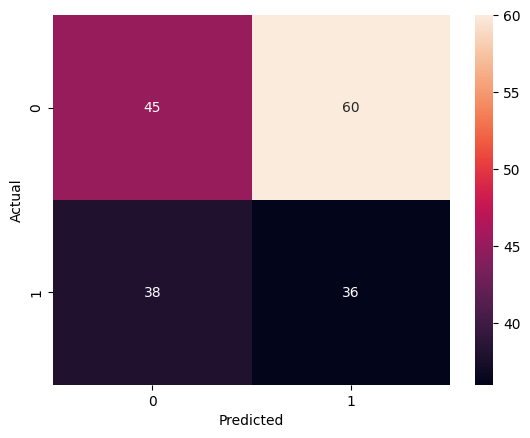

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()